In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
test = pd.read_csv(r'../test.csv')
train = pd.read_csv(r'../train.csv')

In [3]:
df = train.copy()

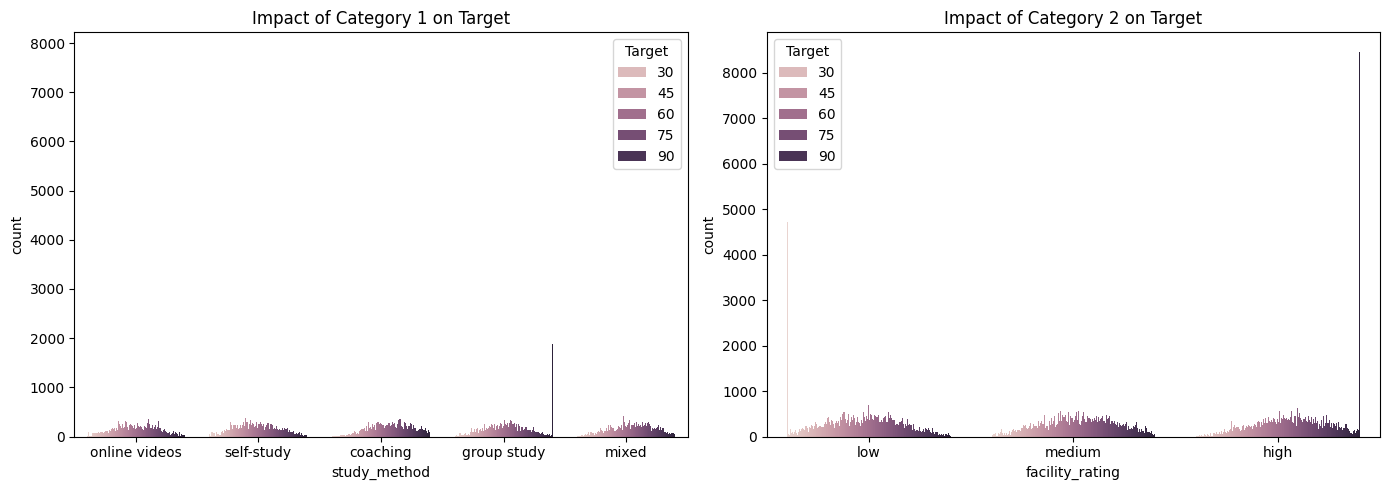

In [5]:
# Assuming df is your DataFrame with 'cat1', 'cat2', and 'target'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot for Categorical Column 1
sns.countplot(data=df, x='study_method', hue='exam_score', ax=axes[0])
axes[0].set_title('Impact of Category 1 on Target')
axes[0].legend(title='Target')

# Plot for Categorical Column 2
sns.countplot(data=df, x='facility_rating', hue='exam_score', ax=axes[1])
axes[1].set_title('Impact of Category 2 on Target')
axes[1].legend(title='Target')

plt.tight_layout()
plt.show()


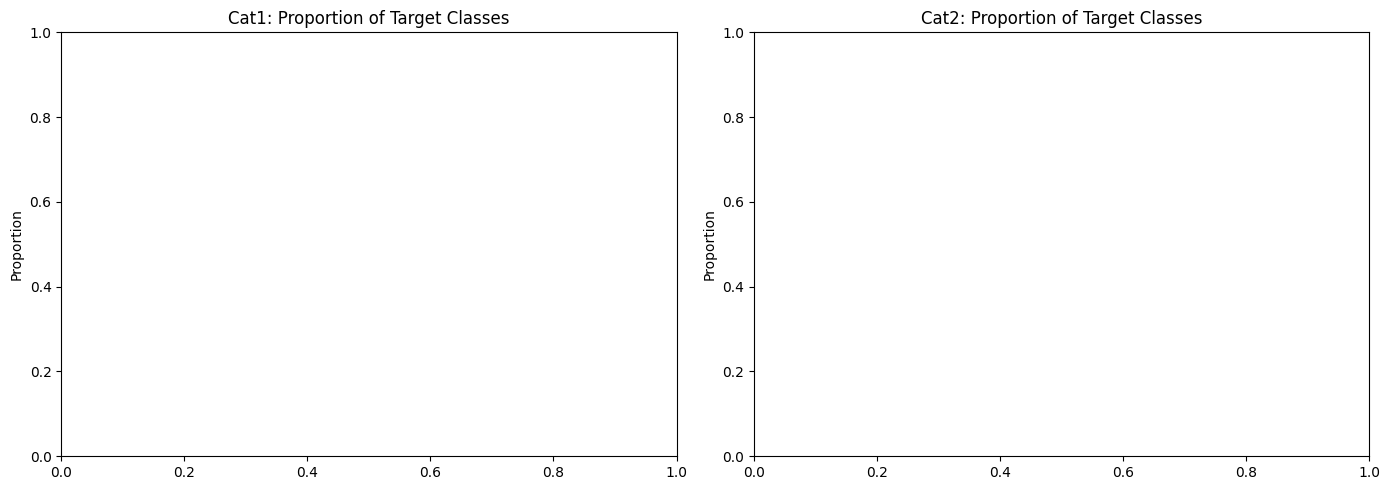

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
target = 'exam_score'
# Normalized proportions for cat1
ct1 = pd.crosstab(df['study_method'], df['exam_score'], normalize='index')
ct1.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')
axes[0].set_title('Cat1: Proportion of Target Classes')
axes[0].set_ylabel('Proportion')

# Normalized proportions for cat2
ct2 = pd.crosstab(df['facility_rating'], df['exam_score'], normalize='index')
ct2.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('Cat2: Proportion of Target Classes')
axes[1].set_ylabel('Proportion')

plt.tight_layout()
plt.show()


C:\Users\16yas\AppData\Local\Temp\ipykernel_23784\3969701643.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x='Feature', y='Chi-Square Statistic', palette='rocket')


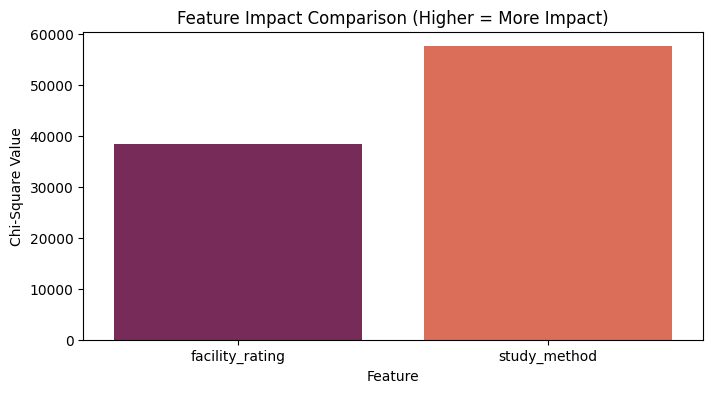

In [10]:
from scipy.stats import chi2_contingency

# Calculate Chi-square statistics
chi2_cat1 = chi2_contingency(pd.crosstab(df['facility_rating'], df['exam_score']))[0]
chi2_cat2 = chi2_contingency(pd.crosstab(df['study_method'], df['exam_score']))[0]

# Visualize
comparison = pd.DataFrame({
    'Feature': ['facility_rating', 'study_method'],
    'Chi-Square Statistic': [chi2_cat1, chi2_cat2]
})

plt.figure(figsize=(8, 4))
sns.barplot(data=comparison, x='Feature', y='Chi-Square Statistic', palette='rocket')
plt.title('Feature Impact Comparison (Higher = More Impact)')
plt.ylabel('Chi-Square Value')
plt.show()


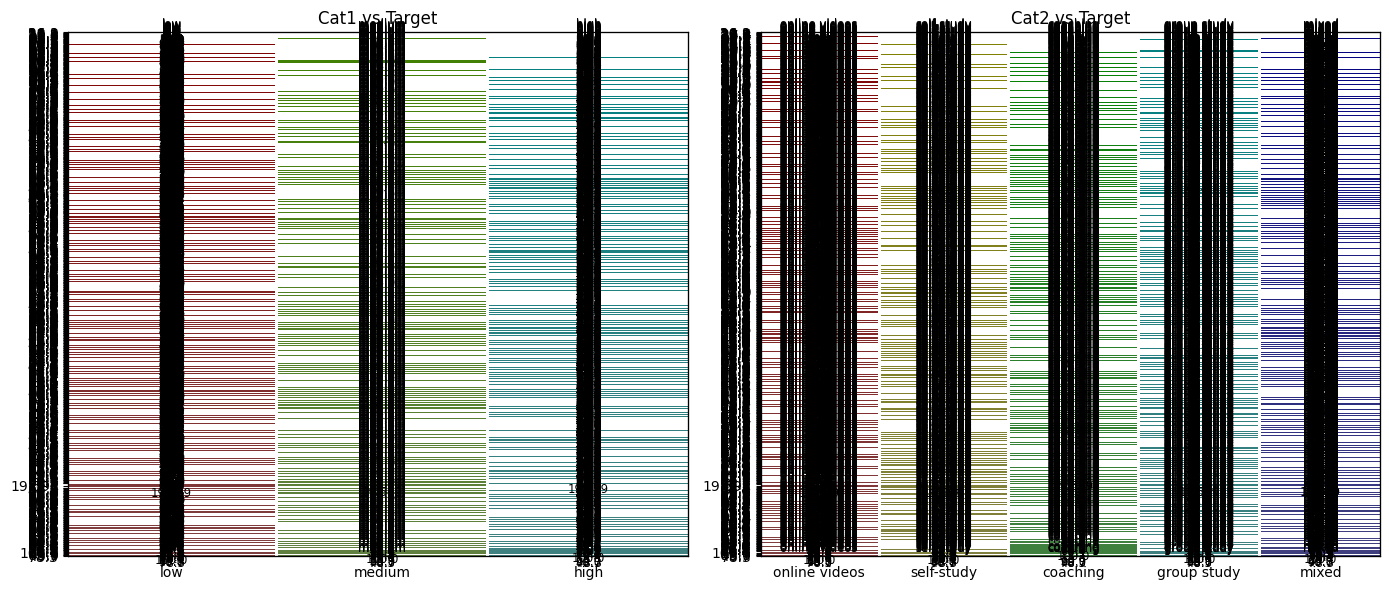

In [11]:
from statsmodels.graphics.mosaicplot import mosaic

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mosaic for cat1
mosaic(df, ['facility_rating', 'exam_score'], ax=axes[0], title='Cat1 vs Target')

# Mosaic for cat2
mosaic(df, ['study_method', 'exam_score'], ax=axes[1], title='Cat2 vs Target')

plt.tight_layout()
plt.show()


In [9]:
df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [10]:
test.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
1,630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
2,630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
3,630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
4,630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [12]:
df.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [19]:
cat_cols = [i for i in df.columns if df[i].dtype=='object']

In [21]:
for i in cat_cols:
    print(df[i].value_counts())
    print("-"*30)

gender
other     211097
male      210593
female    208310
Name: count, dtype: int64
------------------------------
course
b.tech     131236
b.sc       111554
b.com      110932
bca         88721
bba         75644
ba          61989
diploma     49924
Name: count, dtype: int64
------------------------------
internet_access
yes    579423
no      50577
Name: count, dtype: int64
------------------------------
sleep_quality
poor       213675
good       213089
average    203236
Name: count, dtype: int64
------------------------------
study_method
coaching         131697
self-study       131131
mixed            123086
group study      123009
online videos    121077
Name: count, dtype: int64
------------------------------
facility_rating
medium    214082
low       212378
high      203540
Name: count, dtype: int64
------------------------------
exam_difficulty
moderate    353982
easy        176540
hard         99478
Name: count, dtype: int64
------------------------------


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.linear_model import ElasticNet


In [58]:
df = train.copy()

# Drop identifier
df = df.drop(columns=["id"])
TARGET = 'exam_score'

numeric_features = [
    "age",
    "study_hours",
    "class_attendance",
    "sleep_hours",
    "sleep_quality",
    "facility_rating",
    "exam_difficulty",
]

categorical_features = [
    "gender",
    "course",
    "internet_access",
    "study_method",
    # "sleep_quality",
    # "facility_rating",
    # "exam_difficulty"

]


# Ordinal encodings
ordinal_maps = {
    "sleep_quality": {"poor": 0, "average": 1, "good": 2},
    "facility_rating": {"low": 0, "medium": 1, "high": 2},
    "exam_difficulty": {"easy": 0, "moderate": 1, "hard": 2},
}

for col, mapping in ordinal_maps.items():
    df[col] = df[col].map(mapping)

# Features / target
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

baseline_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)),
    ]
)


In [59]:
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

print("Baseline ElasticNet")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Baseline ElasticNet
MAE: 7.165716026672598
RMSE: 8.954419190172416
R2: 0.7745472675162464


In [38]:
sub = test.copy()
for col, mapping in ordinal_maps.items():
    sub[col] = sub[col].map(mapping)

sub_df = sub[['id']]

sub_df[TARGET] = baseline_model.predict(sub)

C:\Users\16yas\AppData\Local\Temp\ipykernel_31560\3811385114.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df[TARGET] = baseline_model.predict(sub)


In [41]:
sub_df.to_csv(r'../submissions/baseline_submission.csv', index=False)

In [69]:
import lightgbm as lgb

df = train.copy()

cat_cols = [
    "gender",
    "course",
    "internet_access",
    "study_method",
]

for col in cat_cols:
    df[col] = df[col].astype("category")

X = df.drop(columns=["exam_score"])
y = df["exam_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_data = lgb.Dataset(
    X_train,
    label=y_train,
    categorical_feature=cat_cols,
)

valid_data = lgb.Dataset(
    X_test,
    label=y_test,
    categorical_feature=cat_cols,
    reference=train_data,
)

params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbosity": -1,
    "seed": 42,
    "early_stopping_rounds": 50,
}

lgb_model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, valid_data],
    num_boost_round=1000,
)

y_pred_lgb = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)

print("LightGBM")
print("MAE:", mean_absolute_error(y_test, y_pred_lgb))
print("RMSE:", root_mean_squared_error(y_test, y_pred_lgb))
print("R2:", r2_score(y_test, y_pred_lgb))


ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: sleep_quality: object, facility_rating: object, exam_difficulty: object

### LightGBM --BaseLine
```
MAE: 6.9794445143718065
RMSE: 8.753519728893997
R2: 0.7845502025405582
```